# Exploratory Data Analysis (EDA)

### 1. Load data and check general info

In [ ]:
import zipfile
import os

zip_filename = 'f11.zip'
destination_dir = './data'

os.makedirs(destination_dir, exist_ok=True)
with zipfile.ZipFile(zip_filename, 'r') as archive:
    archive.extractall(path=destination_dir)

In [ ]:
#!/usr/bin/env python3
import pandas as pd
import os
from pathlib import Path

# Configuration
RAW_DATA_DIR = "./data/f11"
CLEANED_DATA_DIR = "./cleaned"
Path(CLEANED_DATA_DIR).mkdir(exist_ok=True)

campaigns = pd.read_csv(os.path.join(RAW_DATA_DIR, 'campaigns.csv'))
first_purchase = pd.read_csv(os.path.join(RAW_DATA_DIR, 'client_first_purchase_date.csv'))
events = pd.read_csv(os.path.join(RAW_DATA_DIR, 'events.csv'))
friends = pd.read_csv(os.path.join(RAW_DATA_DIR, 'friends.csv'))
messages = pd.read_csv(os.path.join(RAW_DATA_DIR, 'messages.csv'))

/tmp/ipykernel_807/2103959368.py:15: DtypeWarning: Columns (7,8,16,17,21,23,25,27,29) have mixed types. Specify dtype option on import or set low_memory=False.
  messages = pd.read_csv(os.path.join(RAW_DATA_DIR, 'messages.csv'))


In [ ]:
data_block = {
    "campaigns":campaigns,
    "first_purchase": first_purchase,
    "events": events,
    "friends": friends,
    "messages": messages
    }

ids_len = 60
for block in data_block.keys():
    shape = data_block[block].shape
    print("="*ids_len)
    print(f"{block}: {shape[0]} rows {shape[1]} columns")
    print("-"*ids_len)
    # display(data_block[block].describe())
    # print("-"*ids_len)
    display(data_block[block].info())
    print("="*ids_len, end="\n\n")

campaigns: 1907 rows 19 columns
------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1907 entries, 0 to 1906
Data columns (total 19 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id                            1907 non-null   int64  
 1   campaign_type                 1907 non-null   object 
 2   channel                       1907 non-null   object 
 3   topic                         1877 non-null   object 
 4   started_at                    1824 non-null   object 
 5   finished_at                   1808 non-null   object 
 6   total_count                   1824 non-null   float64
 7   ab_test                       12 non-null     object 
 8   warmup_mode                   1830 non-null   object 
 9   hour_limit                    31 non-null     float64
 10  subject_length                1880 non-null   float64
 11  subject_with_personalization

None


first_purchase: 176162 rows 4 columns
------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 176162 entries, 0 to 176161
Data columns (total 4 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   client_id            176162 non-null  int64 
 1   first_purchase_date  176162 non-null  object
 2   user_id              176162 non-null  int64 
 3   user_device_id       176162 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 5.4+ MB


None


events: 1290282 rows 9 columns
------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1290282 entries, 0 to 1290281
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype  
---  ------         --------------    -----  
 0   event_time     1290282 non-null  object 
 1   event_type     1290282 non-null  object 
 2   product_id     1290282 non-null  int64  
 3   category_id    1290282 non-null  int64  
 4   category_code  960110 non-null   object 
 5   brand          1114943 non-null  object 
 6   price          1290282 non-null  float64
 7   user_id        1290282 non-null  int64  
 8   user_session   1290282 non-null  object 
dtypes: float64(1), int64(3), object(5)
memory usage: 88.6+ MB


None


friends: 1974239 rows 2 columns
------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1974239 entries, 0 to 1974238
Data columns (total 2 columns):
 #   Column   Dtype
---  ------   -----
 0   friend1  int64
 1   friend2  int64
dtypes: int64(2)
memory usage: 30.1 MB


None


messages: 3009333 rows 34 columns
------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3009333 entries, 0 to 3009332
Data columns (total 34 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   id                     int64  
 1   message_id             object 
 2   campaign_id            int64  
 3   message_type           object 
 4   client_id              int64  
 5   channel                object 
 6   category               float64
 7   platform               object 
 8   email_provider         object 
 9   stream                 object 
 10  date                   object 
 11  sent_at                object 
 12  is_opened              object 
 13  opened_first_time_at   object 
 14  opened_last_time_at    object 
 15  is_clicked             object 
 16  clicked_first_time_at  object 
 17  clicked_last_time_at   object 
 18  is_unsubscribed        object 
 19  unsubscribed_at        object 

None

### 2. Check Categorical and Numerica columns

In [ ]:
def print_cat_num(df):
    cat_col = [col for col in df.columns if df[col].dtype == 'object']
    num_col = [col for col in df.columns if df[col].dtype != 'object']

    print('Categorical columns:', cat_col)
    print('Numerical columns:', num_col)

for block in data_block.keys():
    print("="*40)
    print(f"{block}:")
    print("-"*40)
    print_cat_num(data_block[block])
    print()

campaigns:
----------------------------------------
Categorical columns: ['campaign_type', 'channel', 'topic', 'started_at', 'finished_at', 'ab_test', 'warmup_mode', 'subject_with_personalization', 'subject_with_deadline', 'subject_with_emoji', 'subject_with_bonuses', 'subject_with_discount', 'subject_with_saleout', 'is_test']
Numerical columns: ['id', 'total_count', 'hour_limit', 'subject_length', 'position']

first_purchase:
----------------------------------------
Categorical columns: ['first_purchase_date']
Numerical columns: ['client_id', 'user_id', 'user_device_id']

events:
----------------------------------------
Categorical columns: ['event_time', 'event_type', 'category_code', 'brand', 'user_session']
Numerical columns: ['product_id', 'category_id', 'price', 'user_id']

friends:
----------------------------------------
Categorical columns: []
Numerical columns: ['friend1', 'friend2']

messages:
----------------------------------------
Categorical columns: ['message_id', 'mess

### 3. Check duplicates

In [ ]:
for block in data_block.keys():
    print("="*40)
    print(f"{block} (duplicates): {data_block[block].duplicated().sum()}", end="\n\n")

campaigns (duplicates): 0

first_purchase (duplicates): 0

events (duplicates): 0

friends (duplicates): 1

messages (duplicates): 0



There is a single duplicated line in friends file.

### 4. Analyse Events

In [ ]:
# Convert event_time to datetime
events['event_time'] = pd.to_datetime(events['event_time'], utc=True)

# Check time range
print(f"Event time range: {events['event_time'].min()} to {events['event_time'].max()}")

# Event type distribution
print("\nEvent type counts:")
print(events['event_type'].value_counts())

Event time range: 2019-10-01 00:00:00+00:00 to 2019-12-31 23:55:44+00:00

Event type counts:
event_type
view        1216009
cart          51188
purchase      23085
Name: count, dtype: int64


In [ ]:
# Product and user uniqueness
print(f"\nUnique products: {events['product_id'].nunique()}")
print(f"Unique users: {events['user_id'].nunique()}")
print(f"Unique sessions: {events['user_session'].nunique()}")


Unique products: 90320
Unique users: 65444
Unique sessions: 282556


In [ ]:
# Number of duplicates
print(f"Number of duplicated rows: {events.duplicated().sum()}")

Number of duplicated rows: 0


In [ ]:
# Missing values
display(pd.DataFrame(events.isna().sum()).T)
# Same in percents
display(pd.DataFrame(100*events.isna().sum()/len(events)).T)

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,0,0,0,0,330172,175339,0,0,0


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,0.0,0.0,0.0,0.0,25.589135,13.5892,0.0,0.0,0.0


For brand we can't just drop rows or impute them as it may lead to bias in features or lost of important data.

In [ ]:
# Check if brand missing coincides with category_code missing
brand_missing = events['brand'].isnull()
catcode_missing = events['category_code'].isnull()
both_missing = (brand_missing & catcode_missing).sum()
print(f"Rows where both brand and category_code are missing: {both_missing} ({both_missing/len(events)*100:.2f}%)")

Rows where both brand and category_code are missing: 86848 (6.73%)


#### 4.1. Category ID and Code

According to description seems like Category Code is a textual form of a Category ID.

In [ ]:
unique_category_code = events.groupby(["category_id"])['category_code'].nunique().sort_values()
print(f"Number of at least 2 unique category codes for each category id: {int((unique_category_code > 1).sum())}")
nan_category_code = events[events['category_id'].isin(unique_category_code[unique_category_code == 0].index)].shape[0]
print(f"Number of rows with NaN category code, where exists not NaN code with corresponding id: {events[events['category_code'].isna()].shape[0]}")
# print(f"Number of rows with NaN category code only: {nan_category_code}")

Number of at least 2 unique category codes for each category id: 0
Number of rows with NaN category code, where exists not NaN code with corresponding id: 330172


According to analysis there is no duplicated Category Codes for unique Category ID. So, it agrees with idea that Category Code is a textual form of a Category ID. There is no NaN Category ID. However, there is NaN Category Code. As for same Category ID value row should have same Category Code value, than lets try to impute NaNs in Category Code by correspondent Category Code values for same Category ID.

In [ ]:
import pandas as pd

def impute_df(df, col_1="col_1", col_2="col_2"):
    """
    Impute NaN values in col_2 based on col_1 grouping.

    For each group defined by col_1, fills NaN in col_2 with the first
    non‑null value found in that group. If a group consists entirely of NaN,
    the values remain NaN.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame with columns 'col_1' and 'col_2'.
    col_1 : str
        First column name.
    col_2 : str
        Second column name.

    Returns
    -------
    pandas.DataFrame
        A new DataFrame with col_2 imputed (original is not modified).
    """
    result = df.copy()
    result[col_2] = result.groupby(col_1)[col_2].transform('first')
    return result

In [ ]:
imputed_events = impute_df(events, col_1="category_id", col_2="category_code")
nan_category_code = imputed_events[imputed_events['category_code'].isna()].shape[0]
print(f"Number of rows with NaN category code only: {nan_category_code}")

Number of rows with NaN category code only: 146590


There was 330172 rows with NaNs in Category Code. After logical imputation we have only 146590 rows with NaNs. It helped to fill many NaNs, but there is still a lot of NaNs. We can't impute them (no such values we can use) or drop such rows (too much rows to lose). Therefore, I will leave cleaning here on this stage.

#### 4.2. User session

In [ ]:
unique_sessions = int((events.groupby(["user_session"])['user_id'].nunique().sort_values() != 1).sum())
print(f"Number of unique user ids grouped by sessions: {unique_sessions}")
print(f"Number of NaN user ids: {int(events["user_id"].isna().sum())}")
print(f"Number of NaN user sessions: {int(events["user_session"].isna().sum())}")

Number of unique user ids grouped by sessions: 0
Number of NaN user ids: 0
Number of NaN user sessions: 0


In [ ]:
events.shape

(1290282, 9)

In [ ]:
282556

Seems that User Session may uniquely identify User ID.

### 5. Analyse First Purchase

In [ ]:
print(f"Number of duplicated rows: {first_purchase.duplicated().sum()}")

Number of duplicated rows: 0


In [ ]:
prefix = "151591562"
client_id = first_purchase.client_id.astype(str)
formed_client_id = prefix + first_purchase.user_id.astype(str) + first_purchase.user_device_id.astype(str)
mismatches = int((client_id != formed_client_id).sum())
print(f"Number of mismatches between client id and derived from prefix + user if + device id: {mismatches}")

Number of mismatches between client id and derived from prefix + user if + device id: 0


In [ ]:
# Missing values
display(pd.DataFrame(first_purchase.isna().sum()).T)
# Same in percents
display(pd.DataFrame(100*first_purchase.isna().sum()/len(first_purchase)).T)

,client_id,first_purchase_date,user_id,user_device_id
0,0,0,0,0


,client_id,first_purchase_date,user_id,user_device_id
0,0.0,0.0,0.0,0.0


In [ ]:
client_user = int((first_purchase.groupby(["client_id"])['user_id'].nunique().sort_values() != 1).sum())
client_device = int((first_purchase.groupby(["client_id"])['user_device_id'].nunique().sort_values() != 1).sum())
print(f"Number of non-unique user ids grouped by client id: {client_user}")
print(f"Number of non-unique device ids grouped by client id: {client_device}")

Number of non-unique user ids grouped by client id: 0
Number of non-unique device ids grouped by client id: 0


All user ids and devices ids are uniqly identified by client id

### 6. Analyse Campaign

In [ ]:
# Distribution of campaign types
print("Campaign type counts:")
print(campaigns['campaign_type'].value_counts())

# Channel distribution
print("\nChannel counts:")
print(campaigns['channel'].value_counts())

# Check date columns
campaigns['started_at'] = pd.to_datetime(campaigns['started_at'], utc=True, errors='coerce')
campaigns['finished_at'] = pd.to_datetime(campaigns['finished_at'], utc=True, errors='coerce')

# Check time range
print()
print(f"Start time range: {campaigns['started_at'].min()} to {campaigns['started_at'].max()}")
print(f"Finish time range: {campaigns['finished_at'].min()} to {campaigns['finished_at'].max()}")

Campaign type counts:
campaign_type
bulk             1830
transactional      50
trigger            27
Name: count, dtype: int64

Channel counts:
channel
mobile_push     1396
email            483
multichannel      27
sms                1
Name: count, dtype: int64

Start time range: 2021-04-30 07:22:36.615023+00:00 to 2023-04-21 15:30:14.136724+00:00
Finish time range: 2021-04-30 07:23:41+00:00 to 2023-04-21 16:09:50+00:00


In [ ]:
print(f"Number of duplicated rows: {campaigns.duplicated().sum()}")

Number of duplicated rows: 0


In [ ]:
# Missing values
display(pd.DataFrame(campaigns.isna().sum()).T)
# Same in percents
display(pd.DataFrame(100*campaigns.isna().sum()/len(campaigns)).T)

,id,campaign_type,channel,topic,started_at,finished_at,total_count,ab_test,warmup_mode,hour_limit,subject_length,subject_with_personalization,subject_with_deadline,subject_with_emoji,subject_with_bonuses,subject_with_discount,subject_with_saleout,is_test,position
0,0,0,0,30,83,99,83,1895,77,1876,27,27,27,27,27,27,27,1880,1883


,id,campaign_type,channel,topic,started_at,finished_at,total_count,ab_test,warmup_mode,hour_limit,subject_length,subject_with_personalization,subject_with_deadline,subject_with_emoji,subject_with_bonuses,subject_with_discount,subject_with_saleout,is_test,position
0,0.0,0.0,0.0,1.573152,4.352386,5.1914,4.352386,99.370739,4.037756,98.37441,1.415836,1.415836,1.415836,1.415836,1.415836,1.415836,1.415836,98.584164,98.741479


In [ ]:
# Check number of unique features grouped by id and campaign type
(campaigns.groupby(["id", "campaign_type"])[[
    'channel', "topic", "started_at",
    "finished_at", "total_count", "ab_test", "warmup_mode", "hour_limit",
    "subject_length", "subject_with_personalization", "subject_with_deadline",
    "subject_with_emoji", "subject_with_bonuses", "subject_with_discount",
    "subject_with_saleout", "is_test", "position"
    ]].nunique() > 1).any()

,0
channel,False
topic,False
started_at,False
finished_at,False
total_count,False
ab_test,False
warmup_mode,False
hour_limit,False
subject_length,False
subject_with_personalization,False


In [ ]:
for channel in campaigns.channel.unique():
    uni = campaigns[campaigns.channel == channel].position.unique()
    print(f"Unique position for {channel} channel: {uni}")
print()
for channel in campaigns.channel.unique():
    uni = campaigns[campaigns.channel == channel].is_test.unique()
    print(f"Unique is_test for {channel} channel: {uni}")

Unique position for mobile_push channel: [nan]
Unique position for email channel: [nan]
Unique position for multichannel channel: [ 0. 11. 12. 10. 13. 14.  4.  1. nan  2.  7.  6.  5.  3.  8.  9.]
Unique position for sms channel: [nan]

Unique is_test for mobile_push channel: [nan]
Unique is_test for email channel: [nan]
Unique is_test for multichannel channel: [False True]
Unique is_test for sms channel: [nan]


In [ ]:
warmup = campaigns[campaigns['warmup_mode'].isna()]['campaign_type'].unique()
no_warmup = campaigns[~campaigns['warmup_mode'].isna()]['campaign_type'].unique()
print(f"Campaign types with warmup mode: {warmup}")
print(f"Campaign types without warmup mode: {no_warmup}")

Campaign types with warmup mode: ['trigger' 'transactional']
Campaign types without warmup mode: ['bulk']


In [ ]:
campaigns.shape

(1907, 19)

According to analysis (many NaNs, columns separability) probably it may be possible to somehow extract several different tables from single Campaigns, based on campaign type and/or channel. However, it may not be feasible to do so, as Campaigns is much smaller in comparison to other datasets,

In [ ]:
composite_dups = campaigns.duplicated(subset=['id', 'campaign_type']).sum()
print(f"Duplicates on (id, campaign_type): {composite_dups}")

Duplicates on (id, campaign_type): 0


Seems that id and campaign_type is composite key

In [ ]:
valid_dates = campaigns[['started_at', 'finished_at']].dropna()
date_issue = (valid_dates['started_at'] > valid_dates['finished_at']).sum()
print(f"Rows where started_at > finished_at: {date_issue}")

Rows where started_at > finished_at: 0


### 7. Analyse Friends

In [ ]:
# Missing values
display(pd.DataFrame(friends.isna().sum()).T)
# Same in percents
display(pd.DataFrame(100*friends.isna().sum()/len(friends)).T)

,friend1,friend2
0,0,0


,friend1,friend2
0,0.0,0.0


In [ ]:
print(f"Number of duplicated rows: {friends.duplicated().sum()}")
print("\n\nDuplicated friends ids:")
display(friends[friends.duplicated()])
print("\n\nDuplicated friends pairs:")
display(friends[(friends['friend1'] == 546810522) & (friends['friend2'] == 558794622)])

Number of duplicated rows: 1


Duplicated friends ids:


,friend1,friend2
1221891,546810522,558794622




Duplicated friends pairs:


,friend1,friend2
423017,546810522,558794622
1221891,546810522,558794622


In [ ]:
import numpy as np

friends_copy = friends.copy()
friends_copy[['friend1', 'friend2']] = np.sort(friends_copy[['friend1', 'friend2']], axis=1)
# print(f"Number of duplicated rows: {friends_copy.duplicated().sum()}")

print(f"Number of duplicated rows with swaps: {friends_copy.duplicated().sum()}")
print("Duplicated friends ids with swaps:")
display(friends_copy[friends_copy.duplicated()])

Number of duplicated rows with swaps: 7
Duplicated friends ids with swaps:


,friend1,friend2
1028927,554757686,554987615
1155096,548863126,561825682
1221891,546810522,558794622
1340572,555335552,563363417
1352797,550693218,554403148
1860891,548920811,560606212
1873400,557928156,564164387


In [ ]:
print(f"Number of self-frienship: {int((friends['friend1'] == friends['friend2']).sum())}")

Number of self-frienship: 0


In [ ]:
# Degree distribution (number of friends per user)
from collections import Counter
degree = Counter()
for _, row in friends.iterrows():
    degree[row['friend1']] += 1
    degree[row['friend2']] += 1
degrees = pd.Series(degree)
print(f"Degree statistics:")
print(degrees.describe())

Degree statistics:
count    656456.000000
mean          6.014840
std           2.430997
min           1.000000
25%           4.000000
50%           6.000000
75%           8.000000
max          21.000000
dtype: float64


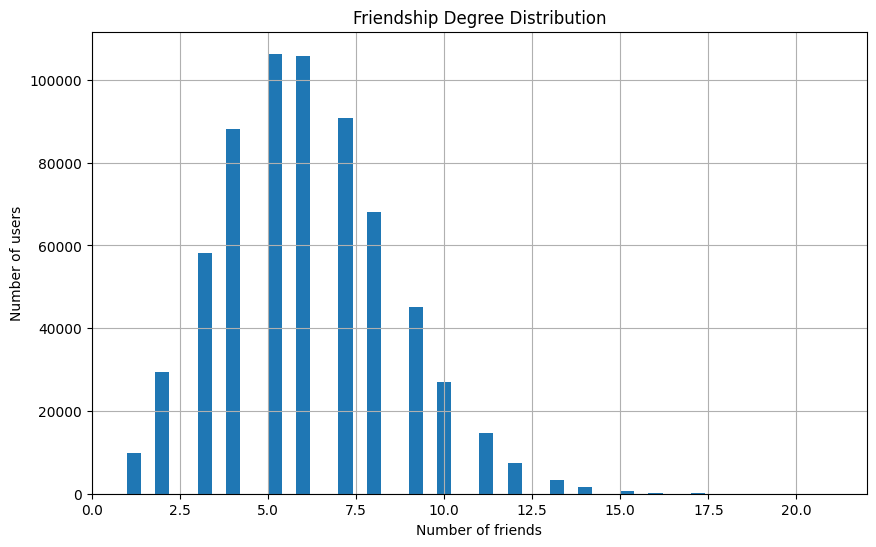

In [ ]:
import matplotlib.pyplot as plt

# Plot degree distribution
plt.figure(figsize=(10,6))
degrees.hist(bins=50)
plt.title('Friendship Degree Distribution')
plt.xlabel('Number of friends')
plt.ylabel('Number of users')
plt.show()

### 8. Analyse Messages

In [ ]:
messages['date'] = pd.to_datetime(messages['date'], utc=True)
messages['sent_at'] = pd.to_datetime(messages['sent_at'], utc=True)
messages['opened_first_time_at'] = pd.to_datetime(messages['opened_first_time_at'], utc=True)
messages['opened_last_time_at'] = pd.to_datetime(messages['opened_last_time_at'], utc=True)
messages['clicked_first_time_at'] = pd.to_datetime(messages['clicked_first_time_at'], utc=True)
messages['clicked_last_time_at'] = pd.to_datetime(messages['clicked_last_time_at'], utc=True)

print(f"Date time range: {messages['date'].min()} to {messages['date'].max()}")
print(f"Sent at time range: {messages['sent_at'].min()} to {messages['sent_at'].max()}")
print(f"Opened first time range: {messages['opened_first_time_at'].min()} to {messages['opened_first_time_at'].max()}")
print(f"Opened last time range: {messages['opened_last_time_at'].min()} to {messages['opened_last_time_at'].max()}")
print(f"Clicked first time range: {messages['clicked_first_time_at'].min()} to {messages['clicked_first_time_at'].max()}")
print(f"Clicked last time range: {messages['clicked_last_time_at'].min()} to {messages['clicked_last_time_at'].max()}")

Date time range: 2021-04-30 00:00:00+00:00 to 2021-06-14 00:00:00+00:00
Sent at time range: 2021-04-30 00:05:45+00:00 to 2021-06-14 23:58:24+00:00
Opened first time range: 2021-04-30 00:08:55+00:00 to 2022-01-20 14:10:46+00:00
Opened last time range: 2021-04-30 00:08:55+00:00 to 2022-01-20 14:10:46+00:00
Clicked first time range: 2021-04-30 00:55:57+00:00 to 2021-11-19 13:40:53+00:00
Clicked last time range: 2021-04-30 00:55:57+00:00 to 2021-11-19 13:40:53+00:00


In [ ]:
# Check cardinality
print(f"Unique client_id: {messages['client_id'].nunique()}")
print(f"Unique campaign_id: {messages['campaign_id'].nunique()}")

Unique client_id: 1007461
Unique campaign_id: 66


In [ ]:
# Message type distribution
print("Message type counts:")
print(messages['message_type'].value_counts())

# Channel distribution
print("\nChannel counts:")
print(messages['channel'].value_counts())

Message type counts:
message_type
bulk             2121331
trigger           645924
transactional     242078
Name: count, dtype: int64

Channel counts:
channel
email          1742210
mobile_push    1267042
web_push            81
Name: count, dtype: int64


In [ ]:
# Check timestamp columns for consistency (e.g., opened_first_time_at <= opened_last_time_at)
opened_valid = messages[['opened_first_time_at', 'opened_last_time_at']].dropna()
if len(opened_valid) > 0:
    opened_first = pd.to_datetime(opened_valid['opened_first_time_at'])
    opened_last = pd.to_datetime(opened_valid['opened_last_time_at'])
    print(f"Rows where opened_first > opened_last: {(opened_first > opened_last).sum()}")

Rows where opened_first > opened_last: 0


In [ ]:
# Duplicated values
print(f"Number of duplicated rows: {messages.duplicated().sum()}")

Number of duplicated rows: 0


In [ ]:
# Missing values
display(messages.isna().sum())
# Same in percents
display(100*messages.isna().sum()/len(messages))

,0
id,0
message_id,0
campaign_id,0
message_type,0
client_id,0
channel,0
category,3009333
platform,2787499
email_provider,1267094
stream,0


,0
id,0.000000
message_id,0.000000
campaign_id,0.000000
message_type,0.000000
client_id,0.000000
channel,0.000000
category,100.000000
platform,92.628466
email_provider,42.105477
stream,0.000000


In [ ]:
# Stream duplicated values
print(len(messages['stream'].unique()))

1


In [ ]:
# Does client_id identify user_id and user_device_id
print(f"Greater than 1 unique user ids grouped by client id: {(messages.groupby(["client_id"])['user_id'].nunique().sort_values() != 1).sum()}")
print(f"Greater than 1 user device ids grouped by client id: {(messages.groupby(["client_id"])['user_device_id'].nunique().sort_values() != 1).sum()}")

Greater than 1 unique user ids grouped by client id: 0
Greater than 1 user device ids grouped by client id: 0


In [ ]:
m_unique = set(messages['client_id'].unique())
fp_unique = set(first_purchase['client_id'].unique())
m_fp_difference = m_unique.difference(fp_unique)
fp_m_difference = fp_unique.difference(m_unique)

len(m_fp_difference), len(fp_m_difference)

(901340, 70041)